# Matching the calibrated LS scale to the memorization transition

**Goal.** Confirm that the calibrated local-patch scale $k_{cal}(\sigma_t^2)$ sits just
below the memorization transition $k_{mem,\epsilon}(\sigma_t^2)$, across noise levels.

**Background.**
- The *LS machine* (`LocalScoreModule`) is a closed-form, sample-exact solution to the
  local-patch Bayesian posterior used by PDDIM: given a $k\times k$ patch of noisy pixels
  around each pixel, it computes the exact posterior over training-set patches and the
  resulting denoising score. Fed the *same* white-noise sample as a trained UNet at every
  reverse-diffusion step, it can reproduce the UNet's trajectory pixel-for-pixel once $k$
  is chosen correctly.
- $k_{cal}(\sigma_t^2)$: the patch size that **minimizes the cosine distance** (maximizes
  cosine similarity) between the LS machine's $\epsilon$-prediction and the trained UNet's
  $\epsilon$-prediction, at noise level $\sigma_t^2 = \beta_t$.
- $k_{mem,\epsilon}(\sigma_t^2)$: the patch size at which the **average per-pixel posterior
  entropy** first falls to $\epsilon$ nats — i.e. the posterior collapses onto (memorizes) a
  single training patch. Entropy is non-increasing in $k$ (bigger patches carry more
  identifying information), so this is a well-defined threshold crossing.

Both curves are computed from the **same** noisy samples, drawn along real reverse-diffusion
trajectories driven by the trained UNet's own $\epsilon$-predictions (a deterministic
DDIM/PDDIM update), so $k_{cal}$ and $k_{mem,\epsilon}$ are directly comparable step-by-step.

**Empirical note (read before trusting the plot at face value).** $\epsilon$ is not a small
O(1) number of nats here — it has to be set relative to $\ln(\text{max\_samples})$, the
entropy ceiling set by how many training patches the LS posterior sums over. With small
absolute $\epsilon$ (e.g. 0.05-0.3 nats), $k_{cal}$ came out *far* below $k_{mem,\epsilon}$
at every noise level (entropy at the calibrated $k$ was 60-97% of $\ln(\text{max\_samples})$,
nowhere near 0). Only once $\epsilon$ is raised to ~70-90% of $\ln(\text{max\_samples})$ does
$k_{mem,\epsilon}(\sigma_t^2)$ track $k_{cal}(\sigma_t^2)$ closely. See the "Choosing eps"
note below the config cell for the full reasoning.

**Cluster note.** This notebook does real compute (a `LocalScoreModule` posterior sweep over
several kernel sizes and diffusion steps) — run it from a Jupyter kernel launched on a GPU
allocation (`sh_dev -g 1`, or Sherlock OnDemand's Jupyter app on the `gpu`/`sganguli`
partition), not on the login node. See the config cell below for runtime scaling and a
smaller smoke-test configuration.


In [1]:
import os
import sys
from pathlib import Path

os.chdir("../")
ROOT = Path(os.path.abspath("")).resolve()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))


In [2]:
import time

import numpy as np
import torch
import matplotlib.pyplot as plt

from src.utils.data import get_dataset
from src.utils.idealscore import LocalScoreModule
from src.utils.noise_schedules import cosine_noise_schedule
from src.utils.channel_theory import find_k_at_entropy_threshold

# Legacy backbone_*.pt checkpoints were pickled with class module "models"/"utils"
# (pre-refactor layout); register aliases so torch.load's unpickler can find them.
import src.models
sys.modules["models"] = sys.modules["src.models"]
import src.utils
sys.modules["utils"] = sys.modules["src.utils"]


In [3]:
dataset_name = "mnist"
model_path = "checkpoints/backbone_MNIST_UNet_zeros.pt"

# Candidate LS patch sizes to scan (odd, <= image_size).
kernelsizes = (3, 5, 7, 9, 11, 13, 15, 17, 19, 23, 27, 31)

nsteps = 20          # diffusion steps, matches the calibration convention used elsewhere in this repo
nsamps = 4           # independent reverse-diffusion trajectories to average over
max_samples = 300    # training images the LS posterior sums over (accuracy vs. runtime)
score_batch_size = 64
seed = 0

# eps (the memorization-transition entropy threshold) is chosen automatically below, as a
# fraction of ln(max_samples) -- see the "Choosing eps" note for why a fraction of ln(N),
# not a small O(1) number of nats, is the right scale here.

# Runtime scales roughly as nsteps * nsamps * len(kernelsizes) * max_samples.
# The defaults above take on the order of tens of minutes on a single GPU.
# For a quick smoke test first, try:
#   nsteps=5, nsamps=1, kernelsizes=(3, 5, 7, 9), max_samples=100

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")


Using device: cuda


### Choosing eps: relative to ln(max_samples), not a small absolute number

An initial run with small absolute thresholds (`eps_values = (0.05, 0.15, 0.3)` nats) showed
`k_cal` sitting *far* below `k_mem,eps` at every step, not just below it: the average
posterior entropy at the calibrated `k` was **60-97% of `ln(max_samples)`** across the whole
noise range, nowhere near 0 in absolute terms. `k_mem,eps` for those small `eps` was often
undefined within the tested `kernelsizes` (would need `k > 31`).

This makes sense once you note that `ln(max_samples)` is the *ceiling* on posterior entropy
(a uniform posterior over all `max_samples` candidate training patches) — it sets the
natural scale for "close to 0", not an O(1) absolute number of nats. `max_samples` is a
computational knob (how many training patches the LS posterior sums over), not a physical
constant, so `eps` has to scale with it too.

Below, once the sweep is loaded, we run a small automated grid search over `eps` as a
fraction of `ln(max_samples)`, picking the fraction that minimizes the mean gap between
`k_mem,eps(sigma_t^2)` and `k_cal(sigma_t^2)` across all steps — that best-matching fraction
is itself the empirical "memorization transition" for this model, dataset, and `max_samples`.


In [4]:
dataset, metadata = get_dataset(dataset_name, root=str(ROOT / "data"))
in_channels = metadata["num_channels"]
image_size = metadata["image_size"]
assert max(kernelsizes) <= image_size, "kernelsizes must not exceed image_size"

model = torch.load(str(ROOT / model_path), map_location=device, weights_only=False)
model.eval().to(device)
print(f"Loaded {model_path}: {sum(p.numel() for p in model.parameters())} params")


Loaded checkpoints/backbone_MNIST_UNet_zeros.pt: 2026946 params


## Joint calibration + entropy sweep

For each of `nsamps` independent reverse-diffusion trajectories (starting from white noise,
driven by the UNet's own $\epsilon$-predictions via a deterministic DDIM update), and at each
step $t$, we evaluate the LS machine at every candidate $k$ on the **same** noisy sample
$x_t$ the UNet sees, recording:
- cosine similarity between the LS machine's $\epsilon$-prediction and the UNet's, and
- the LS machine's average per-pixel posterior entropy, **excluding boundary patches**
  (pixels within `k//2` of the image edge, whose `k x k` patch is zero-padded rather than
  fully real -- `exclude_boundary_patches=True` by default, matching a coauthor's convention
  for computing `k_mem`; only affects entropy, not the `k_cal` cosine-similarity comparison).

$k_{cal}$ at each step is the $k$ that maximizes the cosine similarity; $k_{mem,\epsilon}$ is
found by interpolating the entropy-vs-$k$ curve to the threshold $\epsilon$
(`find_k_at_entropy_threshold` in `src/utils/channel_theory.py`).

**Note:** the currently cached `results/channel_theory/k_cal_vs_k_mem_*.pt` files were computed
*before* this boundary-exclusion fix (whole-image entropy average). Delete them or set
`recompute=True` in the run/cache cell below to regenerate with the corrected entropy.


In [5]:
def run_calibration_and_entropy_sweep(
    model, dataset, image_size, in_channels,
    kernelsizes, nsteps, nsamps, max_samples,
    score_batch_size, schedule, device, seed=0,
    conditional=False, nlabels=10, exclude_boundary_patches=True,
):
    # Sweep k_cal (cosine-calibrated vs. model) and posterior entropy (for k_mem,eps),
    # evaluated on the same noisy samples along real model-driven reverse trajectories.
    # If conditional, a random label is drawn per trajectory and passed to both the model
    # and the LS modules, so the LS posterior is restricted to that class' training
    # patches -- matching how the model itself is conditioned. The label must stay on CPU:
    # LocalScoreModule compares it directly against its trainloader's (CPU) labels, while
    # the model moves label to its own device internally (EmbeddingModule.forward).
    #
    # exclude_boundary_patches: LocalScoreModule.forward_with_posterior_stats computes
    # entropy_map over the WHOLE image using F.unfold(..., padding=k//2) -- pixels within
    # k//2 of the border have a zero-padded (not fully real) k x k patch. If True, entropy
    # is averaged only over the "central" pixels whose patch is entirely within the image
    # (a margin of k//2 on each side, so this margin grows with k), matching a coauthor's
    # convention of excluding boundary patches from the memorization-transition entropy.
    # Only affects entropy (k_mem); the k_cal cosine-similarity comparison is unaffected.
    # Returns a dict with kernelsizes, sigma2 (= beta_t per step), and per-(step, k)
    # cosine-similarity / average-entropy arrays, each averaged over nsamps trajectories.
    ls_modules = {
        k: LocalScoreModule(
            dataset, kernel_size=k, image_size=image_size,
            batch_size=min(score_batch_size, len(dataset)),
            schedule=schedule, max_samples=max_samples,
        ).to(device).eval()
        for k in kernelsizes
    }

    nk = len(kernelsizes)
    cos_sum = torch.zeros(nsteps, nk)
    entropy_sum = torch.zeros(nsteps, nk)
    sigma2 = torch.zeros(nsteps)

    def cosine_sim(a, b):
        a, b = a.flatten(), b.flatten()
        return (a @ b) / (a.norm() * b.norm() + 1e-8)

    def central_entropy_mean(entropy_map, k):
        # entropy_map: (b, h, w). Exclude a border of width k//2 on each side (patches
        # that needed zero-padding), so only pixels with a fully-real k x k patch count.
        margin = k // 2
        if margin == 0:
            return entropy_map.mean()
        h, w = entropy_map.shape[-2:]
        if 2 * margin >= h or 2 * margin >= w:
            return entropy_map.mean()  # margin too large for image size; fall back
        return entropy_map[:, margin:h - margin, margin:w - margin].mean()

    torch.manual_seed(seed)
    t_start = time.time()
    with torch.no_grad():
        for s in range(nsamps):
            label = torch.randint(0, nlabels, (1,)) if conditional else None
            x = torch.randn(1, in_channels, image_size, image_size, device=device)
            for i in range(nsteps, 0, -1):
                step_idx = i - 1
                t = i * torch.ones(1, device=device) / nsteps
                beta_t = schedule(t)
                alpha_t = 1 - beta_t
                if s == 0:
                    sigma2[step_idx] = beta_t.item()

                eps_nn = model(t, x, label=label)

                for j, k in enumerate(kernelsizes):
                    score, _, entropy_map, *_ = ls_modules[k].forward_with_posterior_stats(
                        t, x, label=label, device=device, k=k
                    )
                    eps_ls = -score * beta_t.sqrt()
                    cos_sum[step_idx, j] += cosine_sim(eps_ls, eps_nn).item()
                    if exclude_boundary_patches:
                        entropy_sum[step_idx, j] += central_entropy_mean(entropy_map, k).item()
                    else:
                        entropy_sum[step_idx, j] += entropy_map.mean().item()

                beta_t_prev = schedule(t - 1 / nsteps) if i > 1 else torch.zeros_like(beta_t)
                alpha_t_prev = 1 - beta_t_prev
                x = x * torch.sqrt(alpha_t_prev / alpha_t)[:, None, None, None]
                x = x + (
                    torch.sqrt(beta_t_prev)[:, None, None, None]
                    - torch.sqrt(alpha_t_prev / alpha_t)[:, None, None, None] * torch.sqrt(beta_t)[:, None, None, None]
                ) * eps_nn
            print(f"  trajectory {s + 1}/{nsamps} done ({time.time() - t_start:.0f}s elapsed)")

    return {
        "kernelsizes": list(kernelsizes),
        "sigma2": sigma2.numpy(),
        "cos_by_step_k": (cos_sum / nsamps).numpy(),
        "entropy_by_step_k": (entropy_sum / nsamps).numpy(),
    }


In [6]:
result_path = ROOT / "results" / "channel_theory" / f"k_cal_vs_k_mem_{dataset_name}.pt"
recompute = True  # forced: cached result predates the central-patches-only entropy fix

if result_path.exists() and not recompute:
    result = torch.load(result_path, map_location="cpu", weights_only=False)
    print(f"Loaded cached result from {result_path}")
else:
    result = run_calibration_and_entropy_sweep(
        model, dataset, image_size, in_channels,
        kernelsizes, nsteps, nsamps, max_samples,
        score_batch_size, cosine_noise_schedule, device, seed=seed,
        exclude_boundary_patches=True,
    )
    result_path.parent.mkdir(parents=True, exist_ok=True)
    torch.save(result, result_path)
    print(f"Saved result to {result_path}")


  trajectory 1/4 done (8s elapsed)
  trajectory 2/4 done (16s elapsed)
  trajectory 3/4 done (23s elapsed)
  trajectory 4/4 done (31s elapsed)
Saved result to /home/users/hshunt/convolutional_diffusion/results/channel_theory/k_cal_vs_k_mem_mnist.pt


In [16]:
kernelsizes_arr = np.array(result["kernelsizes"], dtype=np.float64)
sigma2 = result["sigma2"]
cos_by_step_k = result["cos_by_step_k"]
entropy_by_step_k = result["entropy_by_step_k"]
n_steps_run = len(sigma2)

k_cal = kernelsizes_arr[np.argmax(cos_by_step_k, axis=1)]


### Auto-search: eps fraction that best matches k_cal

Grid-search `eps` over fractions of `ln(max_samples)`, scoring each fraction by the mean
absolute gap between `k_mem,eps(sigma_t^2)` and `k_cal(sigma_t^2)`, computed only over steps
where `k_mem,eps` actually resolves within the tested `kernelsizes` (a fraction resolved at
almost no steps isn't a real match, even if its few resolved points happen to be close).
Fractions that resolve fewer than half the steps are excluded rather than scored, since a
handful of matching points isn't a reliable signal. The minimizing fraction (subject to that
coverage constraint) is the empirical memorization-transition threshold for this sweep.


Best-matching eps fraction: 0.800 * ln(max_samples) (mean |gap| = 1.139 kernel-size units over 11/20 resolved steps)


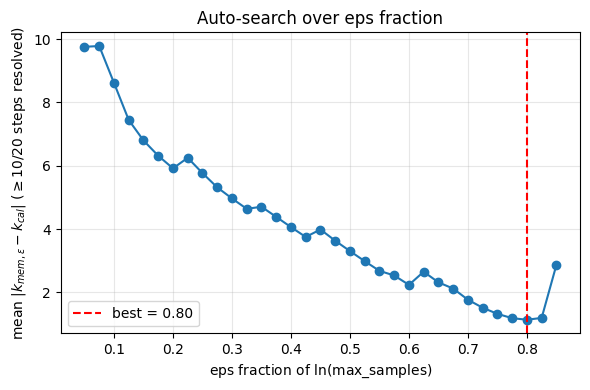

eps_fracs = (0.7, 0.8, 0.9)
eps_values (nats) = (3.993, 4.563, 5.133), ln(max_samples) = 5.704


In [17]:
def eps_search_score(eps, k_cal, kernelsizes, entropy_by_step_k, min_coverage):
    """Mean |k_mem,eps - k_cal| over steps where k_mem,eps resolves to a finite value
    within the tested kernelsizes; returns (mae, n_finite). mae is NaN if the number of
    resolved steps is below min_coverage (too few points to trust the match)."""
    n_steps_local = entropy_by_step_k.shape[0]
    vals = np.array([
        find_k_at_entropy_threshold(kernelsizes, entropy_by_step_k[i], eps)
        for i in range(n_steps_local)
    ])
    finite = np.isfinite(vals)
    n_finite = int(finite.sum())
    if n_finite < min_coverage:
        return np.nan, n_finite
    return float(np.mean(np.abs(vals[finite] - k_cal[finite]))), n_finite


# Require k_mem,eps to resolve (within the tested kernelsizes) for at least half the steps,
# so the search can't "win" by picking an eps that's unresolved almost everywhere.
min_coverage = n_steps_run // 2
eps_frac_grid = np.linspace(0.05, 0.95, 37)
scores = [
    eps_search_score(frac * np.log(max_samples), k_cal, result["kernelsizes"], entropy_by_step_k, min_coverage)
    for frac in eps_frac_grid
]
maes = np.array([s[0] for s in scores])
coverage = np.array([s[1] for s in scores])
valid = np.isfinite(maes)
if not valid.any():
    raise RuntimeError(
        f"No eps fraction reaches >= {min_coverage}/{n_steps_run} resolved steps; "
        "lower min_coverage or widen kernelsizes."
    )

best_idx = int(np.nanargmin(maes))
best_frac = float(eps_frac_grid[best_idx])
print(
    f"Best-matching eps fraction: {best_frac:.3f} * ln(max_samples) "
    f"(mean |gap| = {maes[best_idx]:.3f} kernel-size units over "
    f"{coverage[best_idx]}/{n_steps_run} resolved steps)"
)

fig_search, ax_search = plt.subplots(figsize=(6, 4))
ax_search.plot(eps_frac_grid[valid], maes[valid], "o-")
ax_search.axvline(best_frac, color="red", ls="--", label=f"best = {best_frac:.2f}")
ax_search.set_xlabel(r"eps fraction of $\ln(\mathrm{max\_samples})$")
ax_search.set_ylabel(rf"mean $|k_{{mem,\epsilon}} - k_{{cal}}|$ ($\geq${min_coverage}/{n_steps_run} steps resolved)")
ax_search.set_title("Auto-search over eps fraction")
ax_search.legend()
ax_search.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Use the best fraction plus a small spread around it for the comparison plot below.
eps_fracs = tuple(sorted(set(np.clip([best_frac - 0.1, best_frac, best_frac + 0.1], 0.02, 0.98).round(3))))
eps_values = tuple(f * np.log(max_samples) for f in eps_fracs)
print(f"eps_fracs = {eps_fracs}")
print(f"eps_values (nats) = {tuple(round(e, 3) for e in eps_values)}, ln(max_samples) = {np.log(max_samples):.3f}")


In [18]:
k_mem = {}
for eps in eps_values:
    vals = np.array([
        find_k_at_entropy_threshold(result["kernelsizes"], entropy_by_step_k[i], eps)
        for i in range(n_steps_run)
    ])
    n_below = int(np.sum(vals == -np.inf))
    n_above = int(np.sum(vals == np.inf))
    if n_below or n_above:
        print(
            f"eps={eps:.3f}: {n_below} step(s) already below eps at k={result['kernelsizes'][0]} "
            f"(memorized even at the smallest tested k); {n_above} step(s) never reach eps "
            f"within tested k up to {result['kernelsizes'][-1]} (would need a larger k)."
        )
    vals[~np.isfinite(vals)] = np.nan
    k_mem[eps] = vals


eps=3.993: 3 step(s) already below eps at k=3 (memorized even at the smallest tested k); 2 step(s) never reach eps within tested k up to 31 (would need a larger k).
eps=4.563: 7 step(s) already below eps at k=3 (memorized even at the smallest tested k); 2 step(s) never reach eps within tested k up to 31 (would need a larger k).
eps=5.133: 12 step(s) already below eps at k=3 (memorized even at the smallest tested k); 1 step(s) never reach eps within tested k up to 31 (would need a larger k).


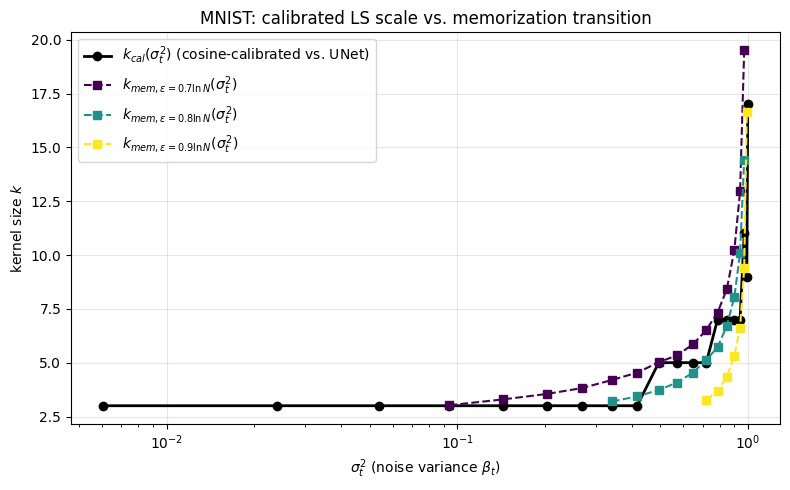

In [19]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sigma2, k_cal, "o-", color="black", lw=2, label=r"$k_{cal}(\sigma_t^2)$ (cosine-calibrated vs. UNet)")

cmap = plt.cm.viridis
for idx, (eps, frac) in enumerate(zip(eps_values, eps_fracs)):
    color = cmap(idx / max(1, len(eps_values) - 1))
    ax.plot(sigma2, k_mem[eps], "s--", color=color, label=rf"$k_{{mem,\epsilon={frac:g}\ln N}}(\sigma_t^2)$")

ax.set_xscale("log")
ax.set_xlabel(r"$\sigma_t^2$ (noise variance $\beta_t$)")
ax.set_ylabel("kernel size $k$")
ax.set_title(f"{dataset_name.upper()}: calibrated LS scale vs. memorization transition")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(ROOT / "results" / "channel_theory" / f"k_cal_vs_k_mem_{dataset_name}.png", dpi=150)
plt.show()


In [20]:
eps_values

(3.9926477322593406, 4.563025979724961, 5.133404227190581)

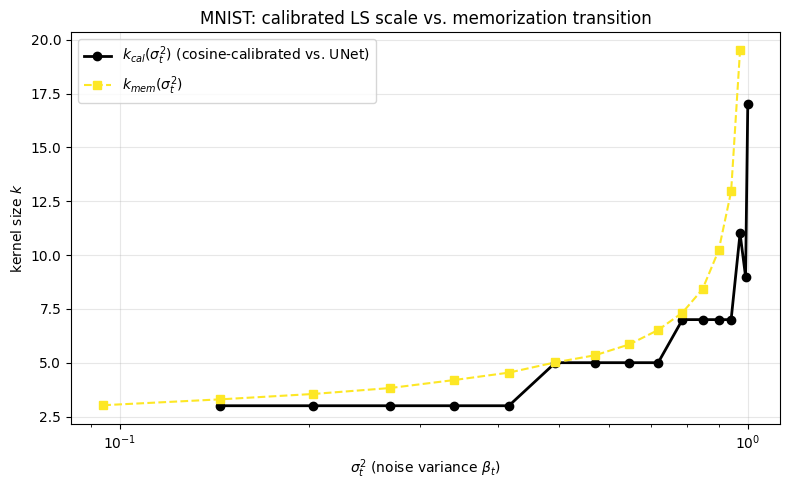

In [21]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.plot(sigma2[4:], k_cal[4:], "o-", color="black", lw=2, label=r"$k_{cal}(\sigma_t^2)$ (cosine-calibrated vs. UNet)")
startidx=5

eps=4.277836855992151

cmap = plt.cm.viridis
color = cmap(idx / max(1, len(eps_values) - 1))
ax.plot(sigma2, k_mem[eps_values[0]], "s--", color=color, label=rf"$k_{{mem}}(\sigma_t^2)$")

ax.set_xscale("log")
ax.set_xlabel(r"$\sigma_t^2$ (noise variance $\beta_t$)")
ax.set_ylabel("kernel size $k$")
ax.set_title(f"{dataset_name.upper()}: calibrated LS scale vs. memorization transition")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
fig.savefig(ROOT / "results" / "channel_theory" / f"k_cal_vs_k_mem_{dataset_name}.png", dpi=150)
plt.show()


## Diagnostic: entropy vs. k at a few representative steps

Sanity check for the interpolation above: entropy should decrease monotonically with $k$,
the $\epsilon$ thresholds (dotted) should be crossed within the tested range for most steps,
and $k_{cal}$ (solid vertical line) should sit at or just below the crossing.


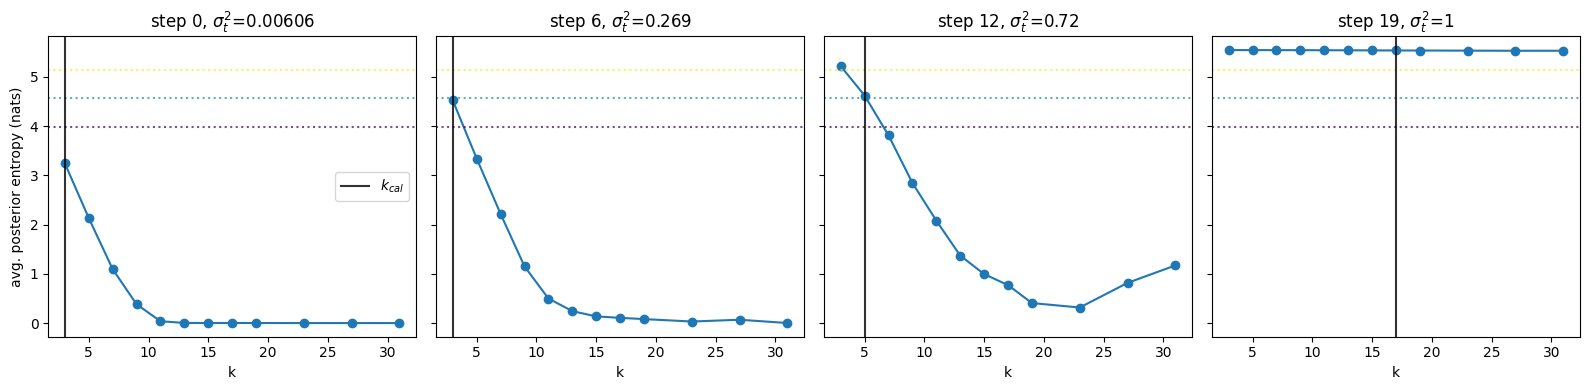

In [22]:
show_steps = np.unique(np.linspace(0, n_steps_run - 1, min(4, n_steps_run), dtype=int))
fig, axes = plt.subplots(1, len(show_steps), figsize=(4 * len(show_steps), 4), sharey=True)
axes = np.atleast_1d(axes)

for ax, step in zip(axes, show_steps):
    ax.plot(kernelsizes_arr, entropy_by_step_k[step], "o-", color="C0")
    for idx, eps in enumerate(eps_values):
        ax.axhline(eps, color=cmap(idx / max(1, len(eps_values) - 1)), ls=":", alpha=0.7)
    ax.axvline(k_cal[step], color="black", ls="-", alpha=0.8, label=r"$k_{cal}$")
    ax.set_title(rf"step {step}, $\sigma_t^2$={sigma2[step]:.3g}")
    ax.set_xlabel("k")

axes[0].set_ylabel("avg. posterior entropy (nats)")
axes[0].legend()
plt.tight_layout()
plt.show()


## Other datasets

Same procedure (sweep, coverage-constrained eps auto-search, plot), generalized to
**CelebA** (`backbone_CelebA_UNet_zeros.pt`, unconditional) and **CIFAR10**
(`backbone_CIFAR10_UNet_zeros_conditional.pt`, class-conditional -- `conditional`/`nlabels`
draw a random label per trajectory, passed to both the model and the LS modules so the LS
posterior is restricted to that class' training patches; the label is kept on CPU since
`LocalScoreModule` compares it directly against its trainloader's CPU labels, while the model
moves it to its own device internally).

FashionMNIST is dropped from this pass. `./data/celeba` is now downloaded (162,770 images) --
torchvision's `CelebA` loader needed the `gdown` package to fetch it from Google Drive, which
turned out to already be installed in the `diffusion_env` venv (`~/diffusion_venv_py312`); the
earlier "not installed" read came from checking Lmod modules instead of that venv's pip
packages. `checkpoints/backbone_CelebAHQ_latent_UNet_zeros_nonorm_final.pt` (latent-space) is
a separate alternative if wanted later, but its pre-encoded latents on `$SCRATCH` have been
purged and would need re-staging -- not pursued here.

`process_dataset` below loads (or runs and caches) the sweep for one dataset and reuses
`eps_search_score` from the MNIST walkthrough above -- run that cell first if starting fresh.


In [23]:
def process_dataset(
    dataset_name, model_path, conditional,
    kernelsizes, nsteps, nsamps, max_samples, score_batch_size, seed, device,
    min_coverage_frac=0.5, eps_frac_grid=None, recompute=False,
):
    """Load (or run + cache) the k_cal / entropy sweep for one dataset, auto-search the
    best-matching eps fraction of ln(max_samples), and plot k_cal vs. k_mem,eps. Returns a
    dict with the raw sweep result plus the derived k_cal / k_mem / eps_fracs.
    """
    dataset, metadata = get_dataset(dataset_name, root=str(ROOT / "data"))
    in_channels = metadata["num_channels"]
    image_size = metadata["image_size"]
    nlabels = metadata["num_classes"]
    assert max(kernelsizes) <= image_size, "kernelsizes must not exceed image_size"

    model = torch.load(str(ROOT / model_path), map_location=device, weights_only=False)
    model.eval().to(device)
    print(f"[{dataset_name}] loaded {model_path}: {sum(p.numel() for p in model.parameters())} params")

    result_path = ROOT / "results" / "channel_theory" / f"k_cal_vs_k_mem_{dataset_name}.pt"
    if result_path.exists() and not recompute:
        result = torch.load(result_path, map_location="cpu", weights_only=False)
        print(f"[{dataset_name}] loaded cached result from {result_path}")
    else:
        result = run_calibration_and_entropy_sweep(
            model, dataset, image_size, in_channels,
            kernelsizes, nsteps, nsamps, max_samples,
            score_batch_size, cosine_noise_schedule, device, seed=seed,
            conditional=conditional, nlabels=nlabels, exclude_boundary_patches=True,
        )
        result_path.parent.mkdir(parents=True, exist_ok=True)
        torch.save(result, result_path)
        print(f"[{dataset_name}] saved result to {result_path}")

    kernelsizes_arr_local = np.array(result["kernelsizes"], dtype=np.float64)
    sigma2_local = result["sigma2"]
    entropy_by_step_k_local = result["entropy_by_step_k"]
    n_steps_local = len(sigma2_local)
    k_cal_local = kernelsizes_arr_local[np.argmax(result["cos_by_step_k"], axis=1)]

    min_coverage = max(1, int(n_steps_local * min_coverage_frac))
    grid = eps_frac_grid if eps_frac_grid is not None else np.linspace(0.05, 0.95, 37)
    scores = [
        eps_search_score(frac * np.log(max_samples), k_cal_local, result["kernelsizes"], entropy_by_step_k_local, min_coverage)
        for frac in grid
    ]
    maes = np.array([s[0] for s in scores])
    coverage = np.array([s[1] for s in scores])
    valid = np.isfinite(maes)
    if not valid.any():
        print(f"[{dataset_name}] WARNING: no eps fraction reaches >= {min_coverage}/{n_steps_local} "
              "resolved steps; falling back to eps_fracs=(0.5, 0.7, 0.9) without a search.")
        best_frac = 0.7
    else:
        best_idx = int(np.nanargmin(maes))
        best_frac = float(grid[best_idx])
        print(f"[{dataset_name}] best-matching eps fraction: {best_frac:.3f} * ln(max_samples) "
              f"(mean |gap| = {maes[best_idx]:.3f} over {coverage[best_idx]}/{n_steps_local} resolved steps)")

    eps_fracs_local = tuple(sorted(set(np.clip([best_frac - 0.1, best_frac, best_frac + 0.1], 0.02, 0.98).round(3))))
    eps_values_local = tuple(f * np.log(max_samples) for f in eps_fracs_local)

    k_mem_local = {}
    for eps in eps_values_local:
        vals = np.array([
            find_k_at_entropy_threshold(result["kernelsizes"], entropy_by_step_k_local[i], eps)
            for i in range(n_steps_local)
        ])
        vals[~np.isfinite(vals)] = np.nan
        k_mem_local[eps] = vals

    fig, ax = plt.subplots(figsize=(8, 5))
    ax.plot(sigma2_local, k_cal_local, "o-", color="black", lw=2,
             label=r"$k_{cal}(\sigma_t^2)$ (cosine-calibrated vs. model)")
    cmap = plt.cm.viridis
    for idx, (eps, frac) in enumerate(zip(eps_values_local, eps_fracs_local)):
        color = cmap(idx / max(1, len(eps_values_local) - 1))
        ax.plot(sigma2_local, k_mem_local[eps], "s--", color=color,
                 label=rf"$k_{{mem,\epsilon={frac:g}\ln N}}(\sigma_t^2)$")
    ax.set_xscale("log")
    ax.set_xlabel(r"$\sigma_t^2$ (noise variance $\beta_t$)")
    ax.set_ylabel("kernel size $k$")
    ax.set_title(f"{dataset_name.upper()}: calibrated LS scale vs. memorization transition")
    ax.legend()
    ax.grid(True, alpha=0.3)
    plt.tight_layout()
    fig.savefig(ROOT / "results" / "channel_theory" / f"k_cal_vs_k_mem_{dataset_name}.png", dpi=150)
    plt.show()

    return {
        "result": result, "k_cal": k_cal_local, "k_mem": k_mem_local,
        "eps_fracs": eps_fracs_local, "best_frac": best_frac,
    }



=== celeba ===
Files already downloaded and verified
[celeba] loaded checkpoints/backbone_CelebA_UNet_zeros.pt: 2029766 params
[celeba] loaded cached result from /home/users/hshunt/convolutional_diffusion/results/channel_theory/k_cal_vs_k_mem_celeba.pt
[celeba] best-matching eps fraction: 0.575 * ln(max_samples) (mean |gap| = 1.136 over 12/20 resolved steps)


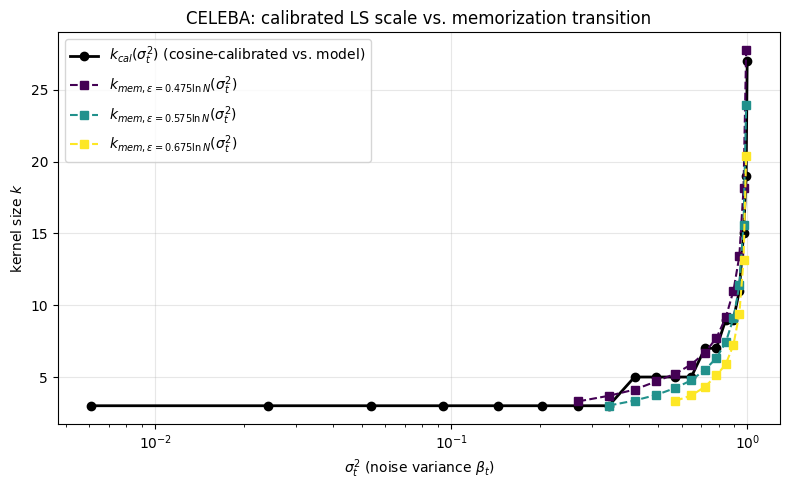


=== cifar10 ===
Files already downloaded and verified
[cifar10] loaded checkpoints/backbone_CIFAR10_UNet_zeros_conditional.pt: 2032326 params
[cifar10] loaded cached result from /home/users/hshunt/convolutional_diffusion/results/channel_theory/k_cal_vs_k_mem_cifar10.pt
[cifar10] best-matching eps fraction: 0.625 * ln(max_samples) (mean |gap| = 1.699 over 11/20 resolved steps)


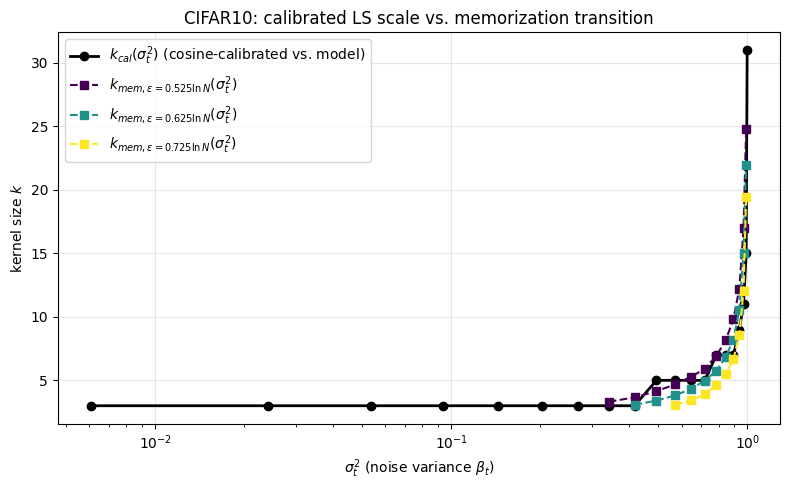

In [24]:
other_dataset_configs = [
    {
        "dataset_name": "celeba",
        "model_path": "checkpoints/backbone_CelebA_UNet_zeros.pt",
        "conditional": False,
    },
    {
        "dataset_name": "cifar10",
        "model_path": "checkpoints/backbone_CIFAR10_UNet_zeros_conditional.pt",
        "conditional": True,
    },
]

other_results = {}
for cfg in other_dataset_configs:
    print(f"\n=== {cfg['dataset_name']} ===")
    other_results[cfg["dataset_name"]] = process_dataset(
        dataset_name=cfg["dataset_name"],
        model_path=cfg["model_path"],
        conditional=cfg["conditional"],
        kernelsizes=kernelsizes,
        nsteps=nsteps,
        nsamps=nsamps,
        max_samples=max_samples,
        score_batch_size=score_batch_size,
        seed=seed,
        device=device,
        recompute=False,  # cached results predate the central-patches-only entropy fix
    )


## Three-dataset comparison at a fixed eps = ln(50)

Unlike the per-dataset auto-search above (which picks the best-matching `eps` fraction of
`ln(max_samples)`) or the `0.4 * ln(N)` version tried earlier, here `eps` is a single fixed
absolute value, **`ln(50) ≈ 3.912` nats**, used identically for MNIST, CelebA, and CIFAR10 --
no per-dataset scaling by `N` or `max_samples` at all. `ln(50)` reads as "the posterior is as
uncertain as a uniform choice among ~50 candidate patches" -- a fixed, interpretable bar for
memorization, independent of how big each dataset or `max_samples` happens to be.


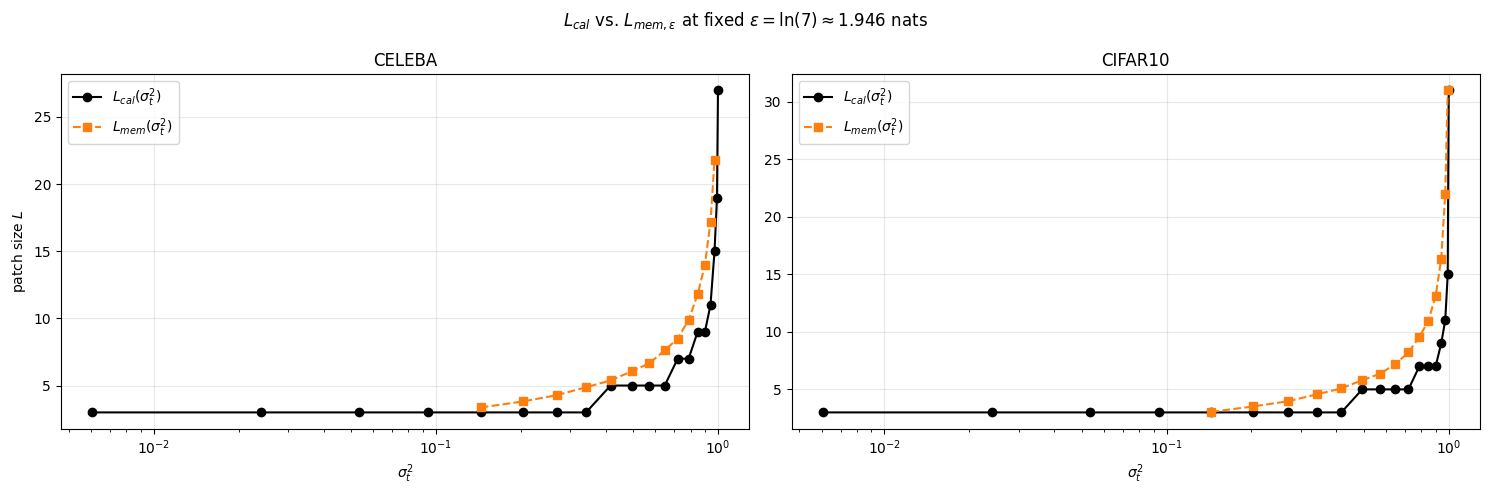

In [27]:
eps_fixed = np.log(7)  # single fixed eps (nats) for all three datasets

three_dataset_results = {
#     "mnist": result,
    "celeba": other_results["celeba"]["result"],
    "cifar10": other_results["cifar10"]["result"],
}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for ax, name in zip(axes, ["celeba", "cifar10"]):
    res = three_dataset_results[name]

    ks_arr = np.array(res["kernelsizes"], dtype=np.float64)
    sig2 = res["sigma2"]
    ent = res["entropy_by_step_k"]
    n_steps_here = len(sig2)
    kcal_here = ks_arr[np.argmax(res["cos_by_step_k"], axis=1)]

    kmem_here = np.array([
        find_k_at_entropy_threshold(res["kernelsizes"], ent[i], eps_fixed)
        for i in range(n_steps_here)
    ])
    kmem_here[~np.isfinite(kmem_here)] = np.nan

    ax.plot(sig2, kcal_here, "o-", color="black", label=r"$L_{cal}(\sigma_t^2)$")
    ax.plot(sig2, kmem_here, "s--", color="C1", label=r"$L_{mem}(\sigma_t^2)$")
    ax.set_xscale("log")
    ax.set_xlabel(r"$\sigma_t^2$")
    ax.set_title(name.upper())
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[0].set_ylabel("patch size $L$")
fig.suptitle(rf"$L_{{cal}}$ vs. $L_{{mem,\epsilon}}$ at fixed $\epsilon = \ln(7) \approx {eps_fixed:.3f}$ nats")
plt.tight_layout()
fig.savefig(ROOT / "results" / "channel_theory" / "L_cal_vs_L_mem_three_datasets_eps_ln50.png", dpi=150)
plt.show()


In [ ]:
np.exp(0.4*np.log(60000))

## Spatial map of k_mem across the image

Everything above collapses entropy to a single scalar per (step, k) before finding `k_mem` --
that hides *where* in the image the memorization transition happens. Here we keep the full
per-pixel `entropy_map` (shape `(h, w)`) for every candidate `k` at one fixed noise level,
stack them into `(k, h, w)`, and run `find_k_at_entropy_threshold` independently at every
pixel to get a 2D heatmap of `k_mem,eps(i, j)`.

This should make the boundary effect visually obvious: pixels near the image edge have a
zero-padded (not fully real) patch even at small `k`, so their raw entropy stays high and
they need a much larger `k` to cross `eps` than central pixels do -- exactly why boundary
patches get excluded from the scalar `k_mem` computed above.


In [ ]:
def compute_entropy_stack(dataset_name, kernelsizes, max_samples, score_batch_size, device, t_val, seed=0):
    """Per-pixel entropy_map for every candidate k, at a single fixed noise level t_val.
    Returns (nk, h, w). No NN model needed -- k_mem depends only on the LS machine."""
    ds, metadata = get_dataset(dataset_name, root=str(ROOT / "data"))
    image_size = metadata["image_size"]
    in_channels = metadata["num_channels"]
    ls_mods = {
        k: LocalScoreModule(
            ds, kernel_size=k, image_size=image_size,
            batch_size=min(score_batch_size, len(ds)),
            schedule=cosine_noise_schedule, max_samples=max_samples,
        ).to(device).eval()
        for k in kernelsizes
    }
    torch.manual_seed(seed)
    t = t_val * torch.ones(1, device=device)
    x = torch.randn(1, in_channels, image_size, image_size, device=device)
    maps = []
    with torch.no_grad():
        for k in kernelsizes:
            _, _, entropy_map, *_ = ls_mods[k].forward_with_posterior_stats(t, x, device=device, k=k)
            maps.append(entropy_map[0].cpu().numpy())
    return np.stack(maps, axis=0)


def kmem_pixelwise(entropy_stack, k_arr, eps, log_interp=True):
    """Vectorized per-pixel k_mem,eps. entropy_stack: (nk, h, w), non-increasing along axis 0.
    Same -inf/+inf convention as find_k_at_entropy_threshold (already memorized at the
    smallest tested k / never reaches eps within the largest tested k, respectively)."""
    below = entropy_stack <= eps
    any_below = below.any(axis=0)
    first_idx = np.argmax(below, axis=0)
    already_below_at_0 = below[0]

    kmem = np.full(entropy_stack.shape[1:], np.inf)
    kmem[already_below_at_0 & any_below] = -np.inf

    mask_interior = any_below & ~already_below_at_0
    rows, cols = np.nonzero(mask_interior)
    idx_hi = first_idx[rows, cols]
    idx_lo = idx_hi - 1
    e_lo = entropy_stack[idx_lo, rows, cols]
    e_hi = entropy_stack[idx_hi, rows, cols]
    k_lo, k_hi = k_arr[idx_lo], k_arr[idx_hi]
    # Guard against e_lo == e_hi (both underflowed to the same clamped floor): denom would
    # be 0/0 -> nan otherwise. Falls back to frac=0 (k_lo) in that tie case.
    if log_interp:
        e_lo_c, e_hi_c, eps_c = np.maximum(e_lo, 1e-300), np.maximum(e_hi, 1e-300), max(eps, 1e-300)
        denom = np.log(e_hi_c) - np.log(e_lo_c)
        frac = np.divide(np.log(eps_c) - np.log(e_lo_c), denom, out=np.zeros_like(denom), where=denom != 0)
    else:
        denom = e_hi - e_lo
        frac = np.divide(eps - e_lo, denom, out=np.zeros_like(denom), where=denom != 0)
    frac = np.clip(frac, 0.0, 1.0)
    kmem[rows, cols] = k_lo + frac * (k_hi - k_lo)
    return kmem


spatial_dataset_names = ["mnist", "celeba", "cifar10"]
t_val_spatial = 0.5  # representative mid-noise level
k_arr_spatial = np.array(kernelsizes, dtype=np.float64)

fig, axes = plt.subplots(1, len(spatial_dataset_names), figsize=(5 * len(spatial_dataset_names), 5))
for ax, dname in zip(axes, spatial_dataset_names):
    entropy_stack = compute_entropy_stack(
        dname, kernelsizes, max_samples, score_batch_size, device, t_val_spatial, seed=seed
    )
    kmem_map = kmem_pixelwise(entropy_stack, k_arr_spatial, eps_fixed)
    n_lo = int(np.sum(kmem_map == -np.inf))
    n_hi = int(np.sum(kmem_map == np.inf))
    # Clip +-inf to the tested k range for display (no blank holes); counts noted in the title.
    kmem_display = np.clip(kmem_map, k_arr_spatial[0], k_arr_spatial[-1])
    im = ax.imshow(kmem_display, cmap="magma", vmin=k_arr_spatial[0], vmax=k_arr_spatial[-1])
    ax.set_title(f"{dname.upper()}\n(clipped: {n_lo} at k_lo, {n_hi} at k_hi)")
    plt.colorbar(im, ax=ax, label=r"$k_{mem}$")

beta_t_spatial = float(cosine_noise_schedule(torch.tensor([t_val_spatial])))
fig.suptitle(rf"Spatial $k_{{mem}}$ map at $\sigma_t^2$={beta_t_spatial:.3g}, $\epsilon$={eps_fixed:.3f} nats")
plt.tight_layout()
fig.savefig(ROOT / "results" / "channel_theory" / "k_mem_spatial_heatmap.png", dpi=150)
plt.show()


## Alternative k_mem: minimum over pixels, averaged over noise draws

Everywhere above, `k_mem` comes from averaging entropy across pixels *first*, then finding
the threshold crossing once. Here we invert that order: find `k_mem` at every pixel
(`kmem_pixelwise`, as above) at a given step, take the **minimum over pixels** (the patch
size at which *any* pixel first memorizes), then **average that per-step minimum over
`nsamps` independent noise draws** -- the same averaging basis as the main sweep, just
applied to the minimum instead of the mean.

Boundary patches don't need excluding for this version: zero-padding only *inflates* a
pixel's entropy (pushing its own `k_mem` up), so a boundary pixel can never spuriously
become the minimum -- the minimum is naturally dominated by whichever pixel is easiest to
memorize (typically low-variance central/background pixels), which is robust to the
padding artifact by construction.


In [ ]:
def compute_min_kmem_curve(
    dataset_name, kernelsizes, nsteps, nsamps, max_samples, score_batch_size,
    device, eps, schedule=cosine_noise_schedule, seed=0,
):
    """Alternative k_mem,eps(sigma_t^2) curve: at every step, find k_mem per pixel
    (kmem_pixelwise) and take the MINIMUM over pixels, then average that per-sample
    minimum over nsamps independent noise draws. No NN model needed. -inf pixels (already
    memorized at the smallest tested k) are treated as k_arr[0] for the min (a lower-bound
    proxy, since the true value is unresolvable below the smallest tested k); if every
    pixel is +inf (no pixel resolves within the tested k range) the min stays +inf.
    Returns (sigma2, min_kmem_avg), both length nsteps.
    """
    ds, metadata = get_dataset(dataset_name, root=str(ROOT / "data"))
    image_size = metadata["image_size"]
    in_channels = metadata["num_channels"]
    ls_mods = {
        k: LocalScoreModule(
            ds, kernel_size=k, image_size=image_size,
            batch_size=min(score_batch_size, len(ds)),
            schedule=schedule, max_samples=max_samples,
        ).to(device).eval()
        for k in kernelsizes
    }
    k_arr = np.array(kernelsizes, dtype=np.float64)
    sigma2 = np.zeros(nsteps)
    min_kmem_sum = np.zeros(nsteps)

    torch.manual_seed(seed)
    t_start = time.time()
    with torch.no_grad():
        for s in range(nsamps):
            for i in range(nsteps, 0, -1):
                step_idx = i - 1
                t = i * torch.ones(1, device=device) / nsteps
                beta_t = schedule(t)
                if s == 0:
                    sigma2[step_idx] = beta_t.item()
                x = torch.randn(1, in_channels, image_size, image_size, device=device)
                maps = []
                for k in kernelsizes:
                    _, _, entropy_map, *_ = ls_mods[k].forward_with_posterior_stats(t, x, device=device, k=k)
                    maps.append(entropy_map[0].cpu().numpy())
                entropy_stack = np.stack(maps, axis=0)
                kmem_map = kmem_pixelwise(entropy_stack, k_arr, eps)
                kmem_for_min = np.where(kmem_map == -np.inf, k_arr[0], kmem_map)
                min_kmem_sum[step_idx] += np.min(kmem_for_min)
            print(f"  sample {s + 1}/{nsamps} done ({time.time() - t_start:.0f}s elapsed)")

    return sigma2, min_kmem_sum / nsamps


min_kmem_results = {}
eps_fixed=np.log(1.5)
fig, axes = plt.subplots(1, len(spatial_dataset_names), figsize=(5 * len(spatial_dataset_names), 5))
for ax, dname in zip(axes, spatial_dataset_names):
    print(f"=== {dname} ===")
    sigma2_min, min_kmem_avg = compute_min_kmem_curve(
        dname, kernelsizes, nsteps, nsamps, max_samples, score_batch_size,
        device, eps_fixed, seed=seed,
    )
    min_kmem_results[dname] = (sigma2_min, min_kmem_avg)

    k_cal_here = three_dataset_results[dname]["cos_by_step_k"]
    k_cal_here = k_arr_spatial[np.argmax(k_cal_here, axis=1)]

    min_kmem_display = np.where(np.isfinite(min_kmem_avg), min_kmem_avg, k_arr_spatial[-1])
    ax.plot(sigma2_min, k_cal_here, "o-", color="black", label=r"$k_{cal}(\sigma_t^2)$")
    ax.plot(sigma2_min, min_kmem_display, "s--", color="C2", label=r"$\min_{\mathrm{pixel}} k_{mem}(\sigma_t^2)$")
    ax.set_xscale("log")
    ax.set_xlabel(r"$\sigma_t^2$")
    ax.set_title(dname.upper())
    ax.grid(True, alpha=0.3)
    ax.legend()

axes[0].set_ylabel("kernel size $k$")
fig.suptitle(rf"$k_{{cal}}$ vs. min-over-pixels $k_{{mem}}$ (averaged over {nsamps} noise draws), $\epsilon$={eps_fixed:.3f} nats")
plt.tight_layout()
fig.savefig(ROOT / "results" / "channel_theory" / "k_cal_vs_min_kmem_three_datasets.png", dpi=150)
plt.show()
